# 06_AM_MHCII_AT2_Spatial_Association
## Xiaonan Wang
## 17Sep2026

In [1]:
#%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from os import listdir
from os.path import isfile, join
import re
import anndata
# import scvi

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', '#a1a1ce', 'purple', '#301934']) 
sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)

In [18]:
import sys

project_dir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1"

if project_dir not in sys.path:
    sys.path.append(project_dir)

import source

In [3]:
sc.logging.print_header()

Package,Version
numpy,2.4.5
matplotlib,3.10.9
scanpy,1.11.5
pandas,2.3.3
anndata,0.12.14
Component,Info
Python,"3.11.6 | packaged by conda-forge | (main, Oct 3 2023, 10:40:35) [GCC 12.3.0]"
OS,Linux-4.18.0-553.81.1.el8_10.x86_64-x86_64-with-glibc2.28
CPU,"16/64 logical CPU cores, x86_64"
GPU,No GPU found


In [3]:
datadir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial/"
outdir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/write_all/"

## Step0 - Read In Files and Set Parameters

In [4]:
x_all = sc.read_h5ad(datadir + "all_updated.h5ad")

In [5]:
import os
if hasattr(os, "sched_getaffinity"):
    print(
        "Available CPUs:",
        len(os.sched_getaffinity(0)),
    )
else:
    print(
        "Available CPUs:",
        os.cpu_count(),
    )

Available CPUs: 17


In [6]:
stage2_common = dict(
    score_col="MHCIIhi_score",
    celltype_col="CellType_refined",
    core_col="core_id",
    donor_col="donor_id",
    tissue_col="tissue_annotation",
    spatial_key="spatial",

    am_labels=("AM", "Alveolar Macrophage"),
    at2_labels=("AT2",),

    coordinate_scale=1.0,

    rename_celltypes={
        "Alveolar Macrophage": "AM",
    },

    min_am_cells=20,
    min_at2_cells=10,

    n_permutations=999,
)

## Step1 - Balanced extremes

In [7]:
stage2_extremes = source.run_stage2_multicore(
    analysis_function=(
        source.calculate_stage2_balanced_extremes_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=301,
    verbose=10,

    radii=(25, 50, 100),
    extreme_fraction=0.25,
    min_extreme_cells=5,

    **stage2_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    3.2s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    3.3s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    3.4s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    3.5s remaining:    1.7s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    3.5s remaining:    0.9s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    3.5s remaining:    0.4s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:    3.6s finished
/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/source.py:8757: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined =

## Step2 - Continuous kNN

In [8]:
stage2_knn = source.run_stage2_multicore(
    analysis_function=(
        source.calculate_stage2_knn_continuum_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=302,
    verbose=10,

    k_values=(5, 15, 30),

    **stage2_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    3.3s remaining:    1.6s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    4.1s remaining:    1.1s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    4.4s remaining:    0.5s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:    5.5s finished
/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/source.py:8757: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined =

## Step3 - Continuous radius

In [9]:
stage2_radius = source.run_stage2_multicore(
    analysis_function=(
        source.calculate_stage2_radius_continuum_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=303,
    verbose=10,

    radii=(25, 50, 100),

    **stage2_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.8s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    3.3s remaining:    1.6s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    4.0s remaining:    1.1s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    4.4s remaining:    0.5s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:    5.6s finished
/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/source.py:8757: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined =

## Step4 - Nearest AT2

In [10]:
stage2_nearest = source.run_stage2_multicore(
    analysis_function=(
        source.calculate_stage2_nearest_at2_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=304,
    verbose=10,

    **stage2_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    1.1s remaining:    0.5s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    1.4s remaining:    0.4s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    1.5s remaining:    0.2s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:    1.9s finished
/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/source.py:8757: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined =

## Step5 - Summarise & Plotting

In [11]:
stage2_results = pd.concat(
    [
        stage2_extremes,
        stage2_knn,
        stage2_radius,
        stage2_nearest,
    ],
    ignore_index=True,
    sort=False,
)

stage2_results = stage2_results.sort_values(
    [
        "method",
        "scale",
        "tissue_annotation",
        "donor_id",
        "core_id",
    ]
).reset_index(drop=True)

display(stage2_results.head())

,method,direction,scale_type,scale,effect_type,core_id,donor_id,tissue_annotation,n_cells,n_am,...,rho_score_at2_fraction,mean_at2_fraction,pct_am_with_at2,mean_at2_neighbors,mean_total_neighbors,rho_score_distance_raw,mean_nearest_distance,median_nearest_distance,q25_nearest_distance,q75_nearest_distance
0,Balanced MHCII extremes,MHCII-high minus MHCII-low,radius_um,25.0,difference,D1.c1,D1,A,6477,164,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Balanced MHCII extremes,MHCII-high minus MHCII-low,radius_um,25.0,difference,D1.c2,D1,A,9387,203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Balanced MHCII extremes,MHCII-high minus MHCII-low,radius_um,25.0,difference,D10.c1,D10,A,7442,1476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Balanced MHCII extremes,MHCII-high minus MHCII-low,radius_um,25.0,difference,D10.c2,D10,A,8542,815,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Balanced MHCII extremes,MHCII-high minus MHCII-low,radius_um,25.0,difference,D11.c2,D11,A,8381,188,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
stage2_donor_summary, stage2_tissue_tests = (
    source.summarize_stage2_by_donor_and_tissue(
        stage2_results,
        min_donors=3,
    )
)

display(stage2_tissue_tests.head())

,method,direction,effect_type,scale_type,scale,tissue_annotation,n_donors,mean_effect,median_effect,wilcoxon_statistic,p_value,FDR
0,Balanced MHCII extremes,MHCII-high minus MHCII-low,difference,radius_um,25.0,A,18,0.031402,0.024607,143.0,0.005203,0.005203
1,Balanced MHCII extremes,MHCII-high minus MHCII-low,difference,radius_um,25.0,B,4,0.079324,0.020527,9.0,0.125000,0.125000
2,Balanced MHCII extremes,MHCII-high minus MHCII-low,difference,radius_um,25.0,None,1,0.225108,0.225108,NaN,NaN,NaN
3,Balanced MHCII extremes,MHCII-high minus MHCII-low,difference,radius_um,25.0,V,13,0.032067,0.015618,70.0,0.047119,0.047119
4,Balanced MHCII extremes,MHCII-high minus MHCII-low,difference,radius_um,50.0,A,19,0.012235,0.009995,131.0,0.078201,0.078201


In [13]:
# ============================================================
# Save all Stage 2 results together
# ============================================================

stage2_results_dict = {
    # Core-level results from the four analyses
    "balanced_extremes": stage2_extremes,
    "knn_continuum": stage2_knn,
    "radius_continuum": stage2_radius,
    "nearest_at2": stage2_nearest,

    # Combined core-level results
    "combined": stage2_results,

    # Donor- and tissue-level summaries
    "donor_summary": stage2_donor_summary,
    "tissue_tests": stage2_tissue_tests,
}

pd.to_pickle(
    stage2_results_dict,
    "Stage2_all_results.pkl.gz",
    compression="gzip",
)

In [14]:
# ============================================================
# Reload all Stage 2 results
# ============================================================

stage2_results_dict = pd.read_pickle(
    "Stage2_all_results.pkl.gz",
    compression="gzip",
)

stage2_extremes = stage2_results_dict["balanced_extremes"]

stage2_knn = stage2_results_dict["knn_continuum"]

stage2_radius = stage2_results_dict["radius_continuum"]

stage2_nearest = stage2_results_dict["nearest_at2"]

stage2_results = stage2_results_dict["combined"]

stage2_donor_summary = stage2_results_dict["donor_summary"]

stage2_tissue_tests = stage2_results_dict["tissue_tests"]

In [21]:
import importlib
import source

importlib.reload(source)

<module 'source' from '/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/source.py'>

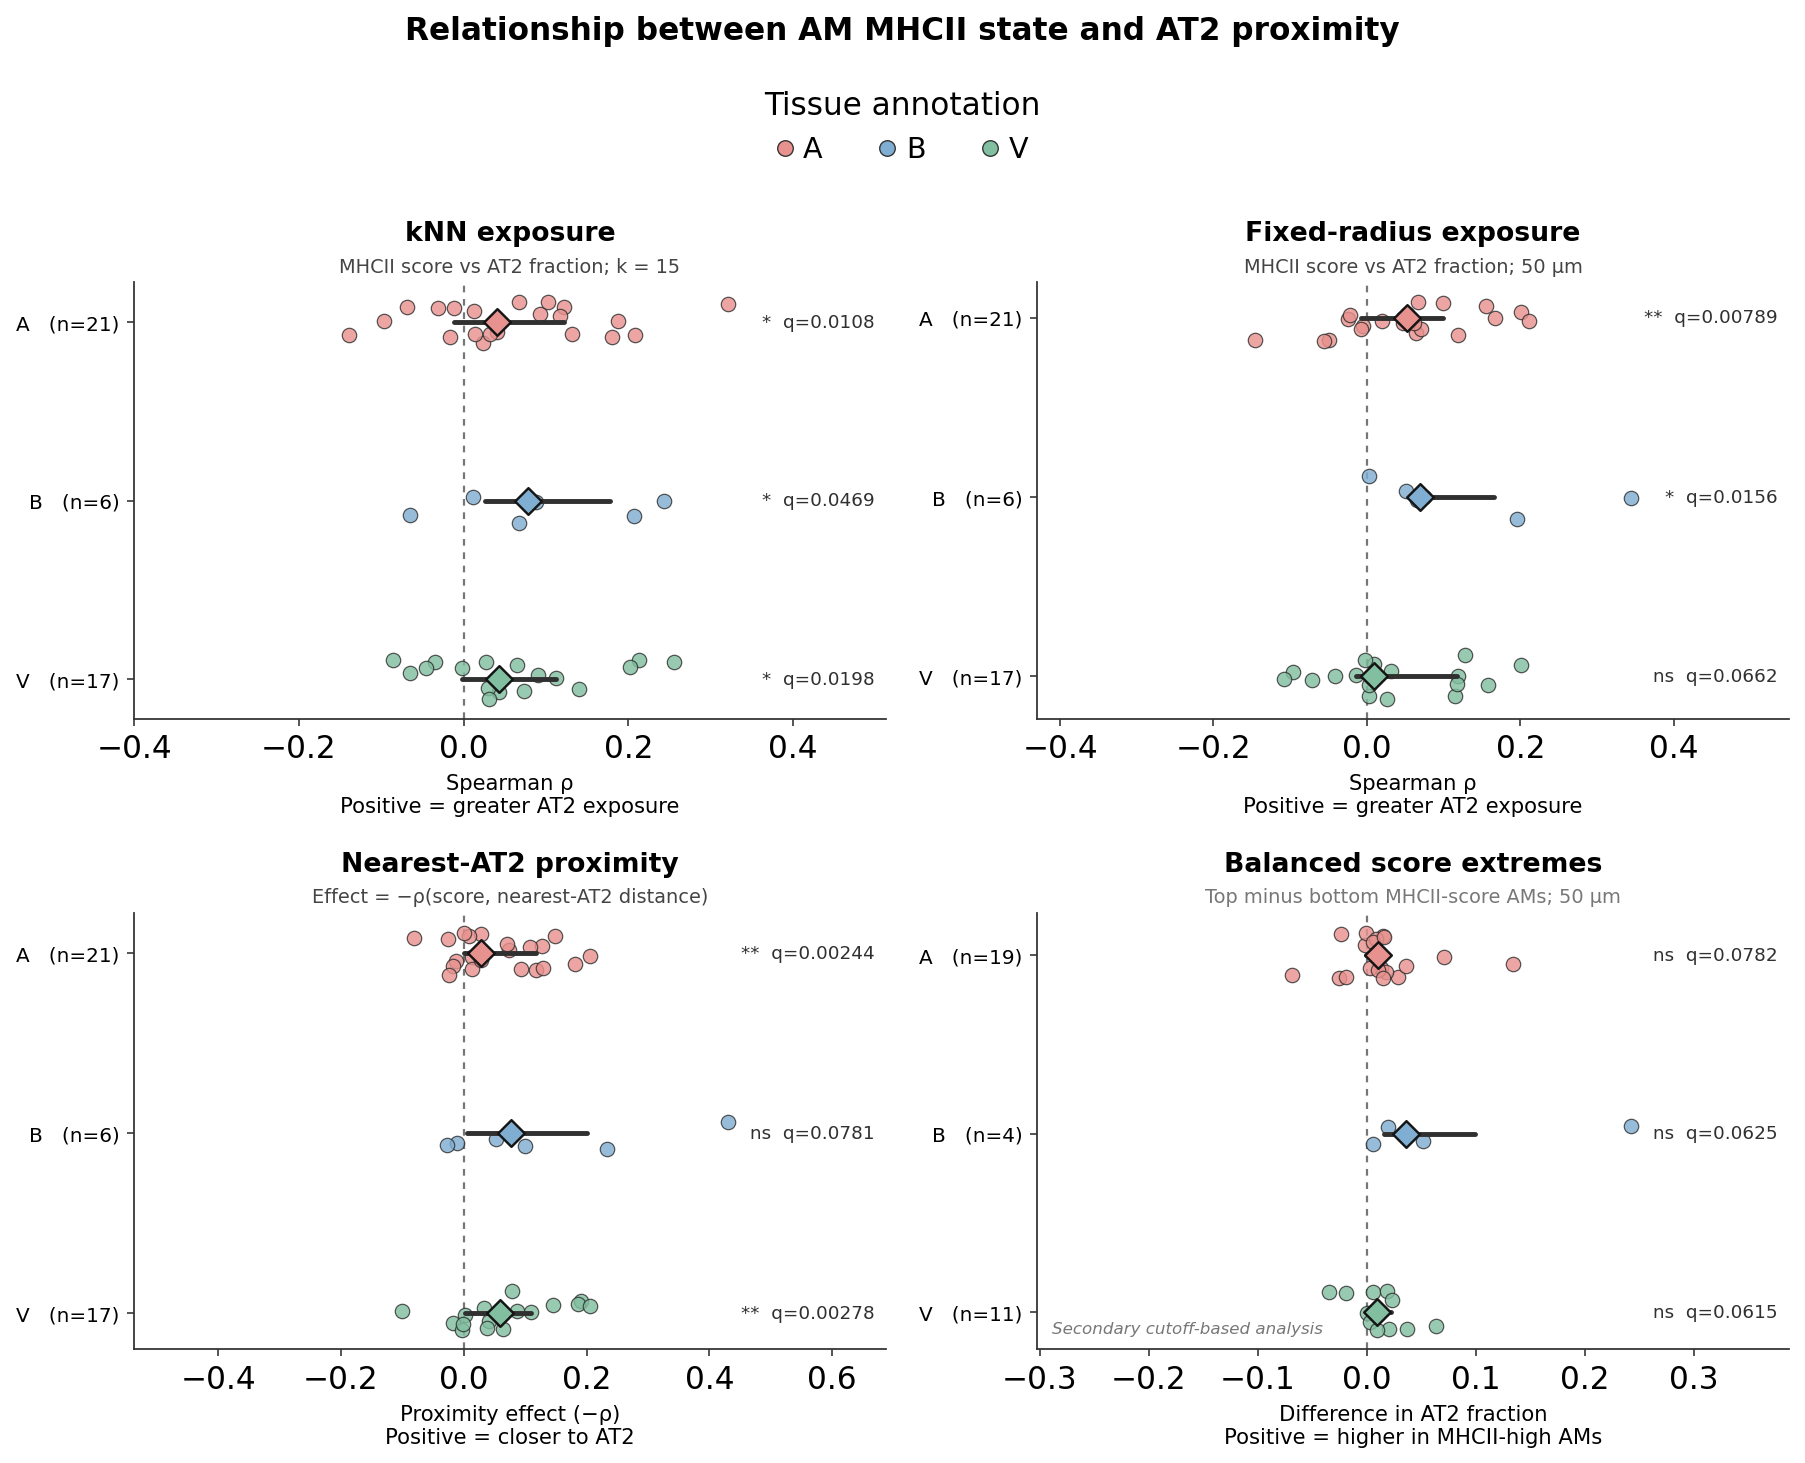

In [22]:
fig, axes, stage2_primary_plot_data = (
    source.plot_stage2_primary(
        donor_summary=stage2_donor_summary,
        tissue_tests=stage2_tissue_tests,
        tissue_order=("A", "B", "V"),
        save="Stage2_MHCII_AT2_primary_results.pdf",
        dpi=300,
    )
)

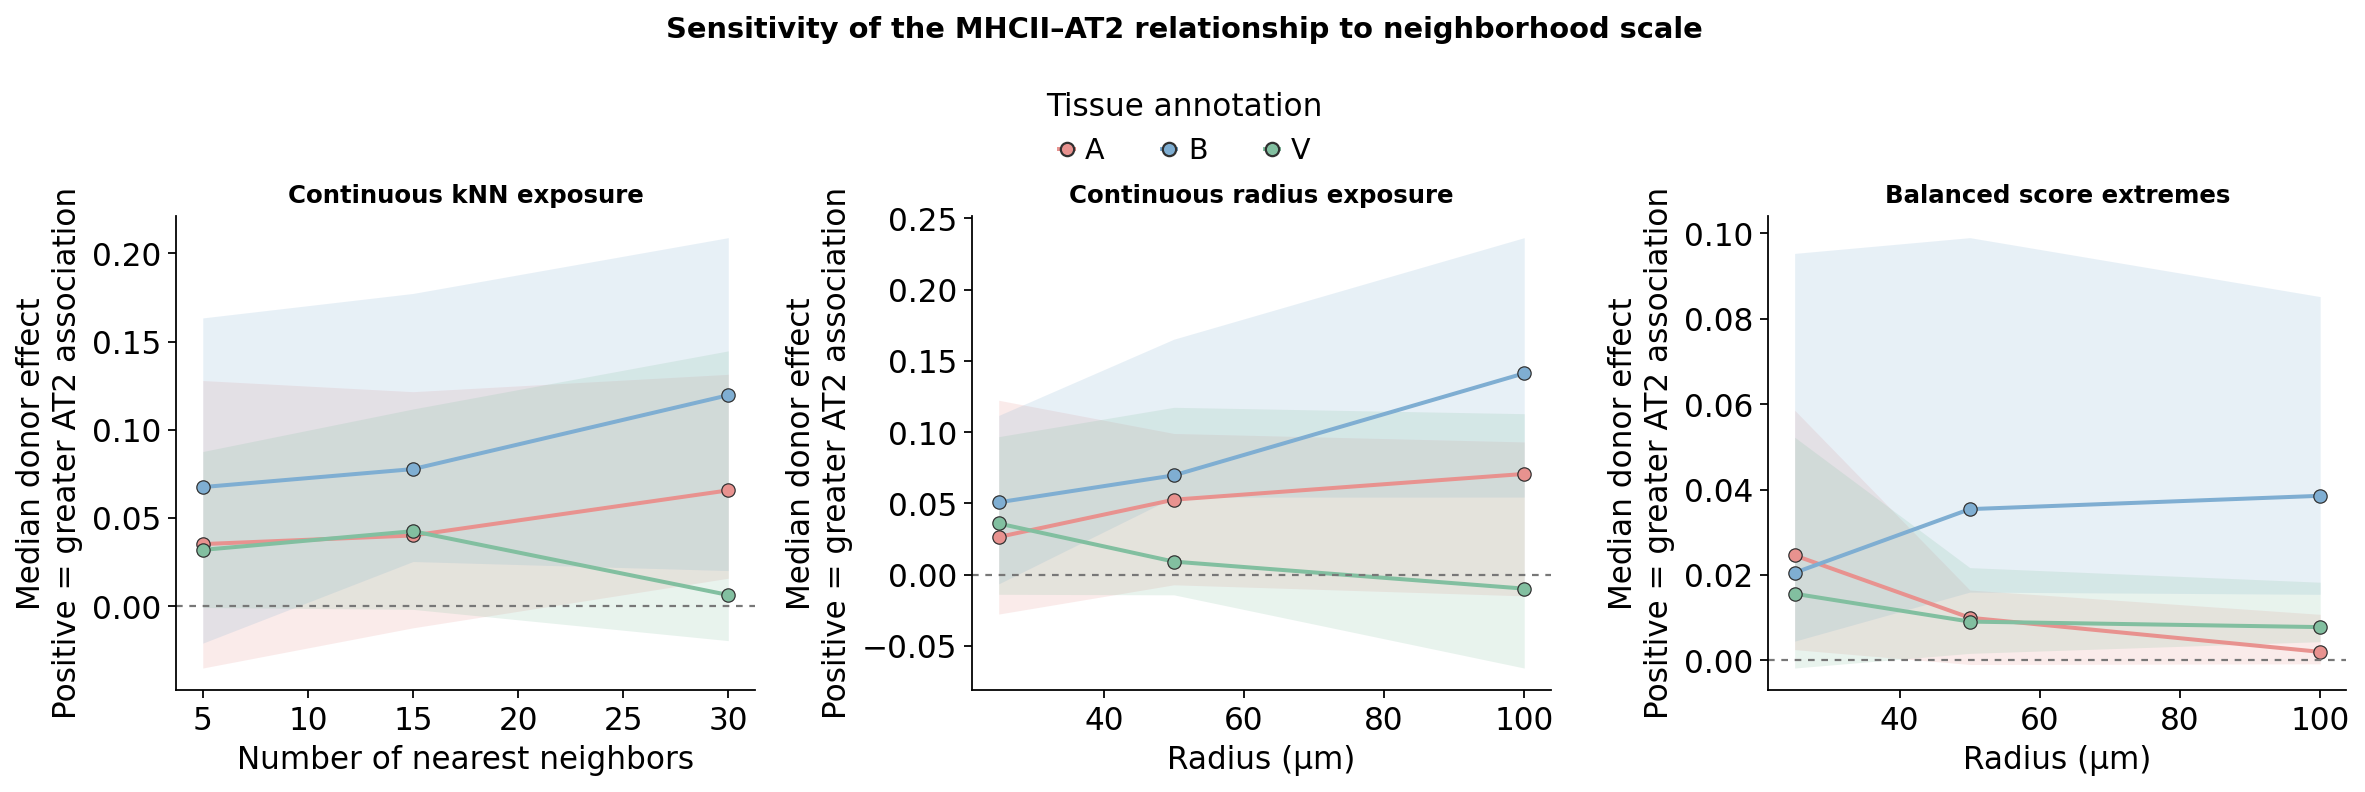

In [25]:
fig, axes, stage2_scale_summary = (
    source.plot_stage2_scale_sensitivity(
        donor_summary=stage2_donor_summary,
        tissue_order=("A", "B", "V"),
        save="Stage2_MHCII_AT2_scale_sensitivity.pdf",
        dpi=300,
    )
)